# Отчёт NL2SQL: режим Pass@K

Ноутбук содержит анализ режима `pass_k` для наборов Spider и BIRD. В этом режиме оценивается вероятность получить хотя бы один корректный SQL-запрос среди нескольких независимых кандидатов.


## 1. Подготовка и источники данных

В разделе фиксируются пути к готовым результатам экспериментов, загружаются JSONL-файлы с предсказаниями и агрегированные метрики. Инференс повторно не запускается: ноутбук работает только с уже сохранёнными артефактами.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent):
    if (candidate / 'nl2sql').exists() and (candidate / 'shared').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'nl2sql' / 'notebooks') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'nl2sql' / 'notebooks'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from analysis_utils import (
    DATA_DIR,
    compute_sample_outcomes,
    ensure_expert_template,
    get_figures_dir,
    get_results_dir,
    load_records,
    load_summary_metrics,
    reset_analysis_caches,
)

RUN_LABEL = 'pass_k'
FIGURES_DIR = get_figures_dir(RUN_LABEL)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
print(f'Using results directory: {get_results_dir()}')
print(f'Run label: {RUN_LABEL}')
print(f'Data directory: {DATA_DIR}')
print(f'Figures directory: {FIGURES_DIR}')


Using results directory: /home/count/code/vkr/results/nl2sql
Run label: pass_k
Data directory: /home/count/code/vkr/data/nl2sql
Figures directory: /home/count/code/vkr/results/nl2sql/figures/pass_k


In [2]:
reset_analysis_caches()
samples_df, generations_df = load_records(RUN_LABEL)
summary_df = load_summary_metrics(RUN_LABEL).copy()
outcomes_df = compute_sample_outcomes(RUN_LABEL).copy()
if 'model_display_name' not in summary_df.columns:
    summary_df['model_display_name'] = summary_df['model_name']
if 'model_display_name' not in outcomes_df.columns:
    outcomes_df['model_display_name'] = outcomes_df['model_name']

expert_path = ensure_expert_template(RUN_LABEL)

print('samples:', samples_df.shape)
print('generations:', generations_df.shape)
print('summary:', summary_df.shape)
print('outcomes:', outcomes_df.shape)
print('expert template/file:', expert_path)

pass_metric_cols = sorted(
    [col for col in summary_df.columns if col.startswith('pass@') and col.split('@', 1)[1].isdigit()],
    key=lambda col: int(col.split('@', 1)[1]),
)
summary_preview_cols = ['model_display_name', 'benchmark', 'run_label', 'n_samples', 'execution_accuracy', *pass_metric_cols]
summary_df[summary_preview_cols].round(4)


samples: (12840, 17)
generations: (64200, 17)
summary: (10, 55)
outcomes: (12840, 30)
expert template/file: /home/count/code/vkr/results/nl2sql/metrics/pass_k/expert_scores_template.csv


,model_display_name,benchmark,run_label,n_samples,execution_accuracy,pass@1,pass@3,pass@5
0,Arctic-Text2SQL-R1-7B,bird,pass_k,1534,0.2132,0.2116,0.2253,0.2347
1,Arctic-Text2SQL-R1-7B,spider,pass_k,1034,0.5522,0.5538,0.5750,0.5890
2,ChatGPT 5.2,bird,pass_k,1534,0.2868,0.2875,0.3524,0.3735
3,ChatGPT 5.2,spider,pass_k,1034,0.7418,0.7424,0.7637,0.7718
4,DeepSeek V3.2,bird,pass_k,1534,0.3175,0.3201,0.3482,0.3611
5,DeepSeek V3.2,spider,pass_k,1034,0.7379,0.7395,0.7619,0.7698
6,Defog-Llama3-SQLCoder-8B q4_0,bird,pass_k,1534,0.1258,0.1279,0.1456,0.1571
7,Defog-Llama3-SQLCoder-8B q4_0,spider,pass_k,1034,0.4323,0.4300,0.4683,0.4942
8,Hrida-T2SQL q8_0,bird,pass_k,1534,0.0378,0.0342,0.0375,0.0404
9,Hrida-T2SQL q8_0,spider,pass_k,1034,0.3414,0.3468,0.3656,0.3772


## 2. Обзор набора данных

Перед анализом `Pass@K` проверяются базовые характеристики текущего среза результатов: число задач по наборам данных, длина вопросов, длина эталонных SQL-запросов и доступные уровни сложности.


,n_samples,mean_question_len,median_question_len,mean_gold_sql_len,median_gold_sql_len
Набор данных,,,,,
BIRD,1534,82.76,79.0,161.47,151.5
Spider,1034,68.05,66.0,106.69,89.0


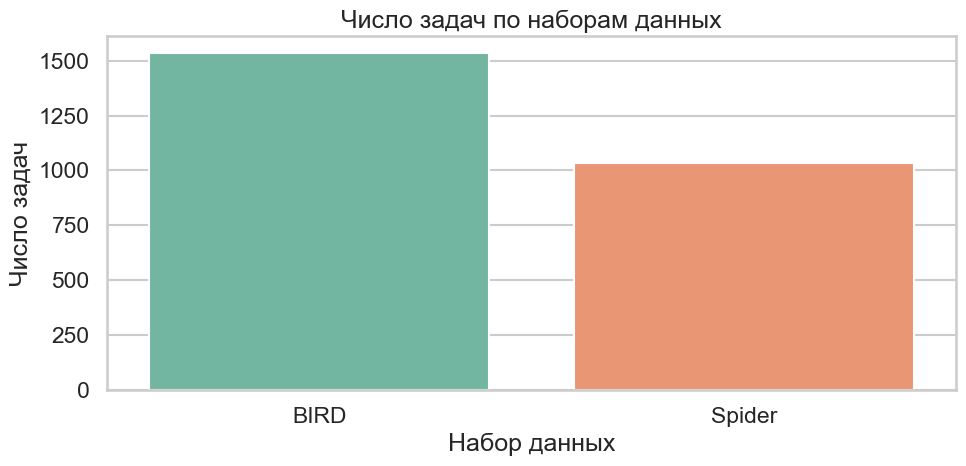

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_samples_ru.png


/tmp/ipykernel_127415/900199362.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


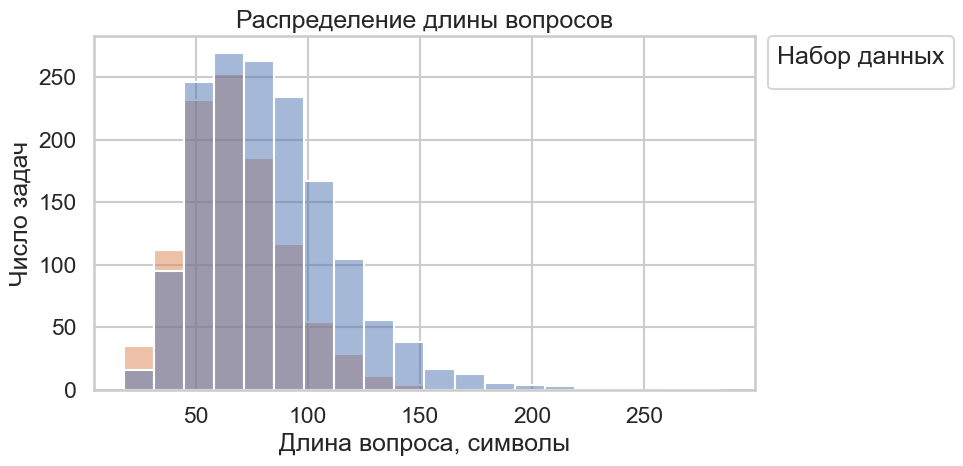

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_question_length_ru.png


/tmp/ipykernel_127415/900199362.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


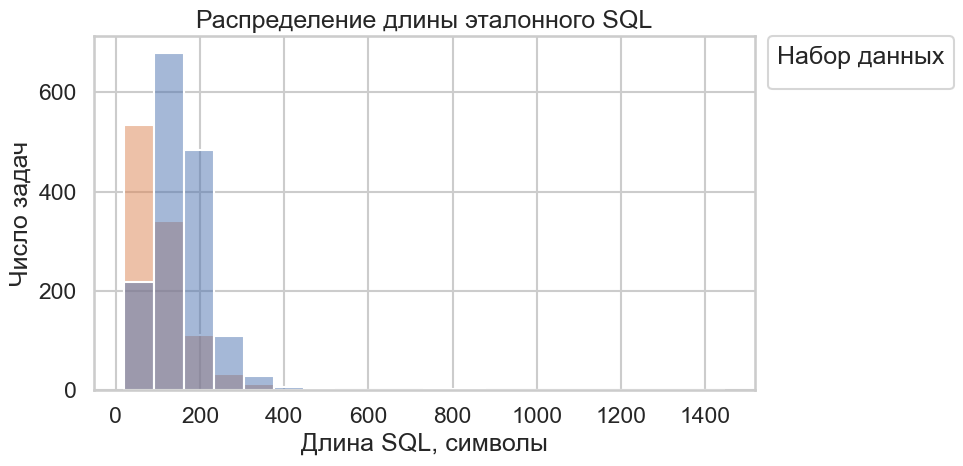

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_gold_sql_length_ru.png


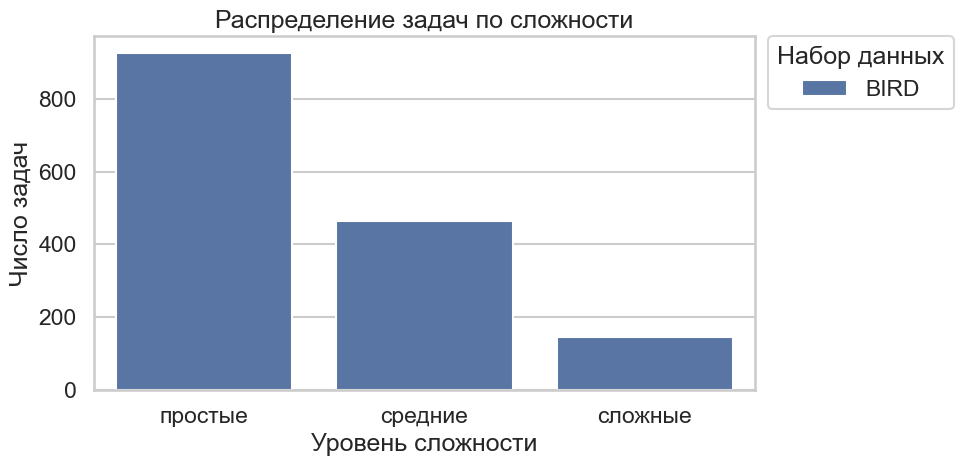

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_difficulty_ru.png
Созданные обзорные графики:
/home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_samples_ru.png
/home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_question_length_ru.png
/home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_gold_sql_length_ru.png
/home/count/code/vkr/results/nl2sql/figures/pass_k/dataset_difficulty_ru.png


In [3]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

if samples_df.empty:
    raise ValueError('Нет raw-данных для отчета.')

unique_samples = (
    samples_df.sort_values(['benchmark', 'sample_id'])
    .drop_duplicates(subset=['benchmark', 'sample_id'])
    .copy()
)
unique_samples['benchmark_ru'] = unique_samples['benchmark'].map(BENCHMARK_LABELS).fillna(unique_samples['benchmark'])
unique_samples['difficulty_ru'] = unique_samples['difficulty'].map(DIFFICULTY_LABELS).fillna(unique_samples['difficulty'])

overview = unique_samples.groupby('benchmark_ru').agg(
    n_samples=('sample_id', 'nunique'),
    mean_question_len=('question_len', 'mean'),
    median_question_len=('question_len', 'median'),
    mean_gold_sql_len=('gold_sql_len', 'mean'),
    median_gold_sql_len=('gold_sql_len', 'median'),
).rename_axis('Набор данных')

display(overview.round(2))
created_figures = []

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=unique_samples, x='benchmark_ru', hue='benchmark_ru', palette='Set2', legend=False, ax=ax)
ax.set_title('Число задач по наборам данных')
ax.set_xlabel('Набор данных')
ax.set_ylabel('Число задач')
path = FIGURES_DIR / 'dataset_samples_ru.png'
_save_current(fig, path)
created_figures.append(path)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=unique_samples, x='question_len', hue='benchmark_ru', bins=20, multiple='layer', ax=ax)
ax.set_title('Распределение длины вопросов')
ax.set_xlabel('Длина вопроса, символы')
ax.set_ylabel('Число задач')
_legend_outside(ax, 'Набор данных')
path = FIGURES_DIR / 'dataset_question_length_ru.png'
_save_current(fig, path)
created_figures.append(path)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=unique_samples, x='gold_sql_len', hue='benchmark_ru', bins=20, multiple='layer', ax=ax)
ax.set_title('Распределение длины эталонного SQL')
ax.set_xlabel('Длина SQL, символы')
ax.set_ylabel('Число задач')
_legend_outside(ax, 'Набор данных')
path = FIGURES_DIR / 'dataset_gold_sql_length_ru.png'
_save_current(fig, path)
created_figures.append(path)

if unique_samples['difficulty'].notna().any():
    difficulty_df = unique_samples.dropna(subset=['difficulty_ru']).copy()
    order = [label for label in ['простые', 'средние', 'сложные'] if label in set(difficulty_df['difficulty_ru'])]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=difficulty_df, x='difficulty_ru', hue='benchmark_ru', order=order or None, ax=ax)
    ax.set_title('Распределение задач по сложности')
    ax.set_xlabel('Уровень сложности')
    ax.set_ylabel('Число задач')
    _legend_outside(ax, 'Набор данных')
    path = FIGURES_DIR / 'dataset_difficulty_ru.png'
    _save_current(fig, path)
    created_figures.append(path)
else:
    print('Сложность задач не указана: график распределения по сложности не создан.')

print('Созданные обзорные графики:')
for path in created_figures:
    print(path)


## 3. Основные результаты

В этом разделе `Pass@K` рассматривается как зависимость качества от числа попыток генерации. Значения `K=1, 3, 5` показывают, как меняется вероятность получить хотя бы один корректный SQL среди нескольких кандидатов. `Execution Accuracy` не добавляется на эту ось, потому что относится к режиму одного ответа и не является ещё одной точкой кривой `Pass@K`.


,model_display_name,benchmark,execution_accuracy,pass@1,pass@3,pass@5
0,Arctic-Text2SQL-R1-7B,bird,0.2132,0.2116,0.2253,0.2347
1,Arctic-Text2SQL-R1-7B,spider,0.5522,0.5538,0.5750,0.5890
2,ChatGPT 5.2,bird,0.2868,0.2875,0.3524,0.3735
3,ChatGPT 5.2,spider,0.7418,0.7424,0.7637,0.7718
4,DeepSeek V3.2,bird,0.3175,0.3201,0.3482,0.3611
5,DeepSeek V3.2,spider,0.7379,0.7395,0.7619,0.7698
6,Defog-Llama3-SQLCoder-8B q4_0,bird,0.1258,0.1279,0.1456,0.1571
7,Defog-Llama3-SQLCoder-8B q4_0,spider,0.4323,0.4300,0.4683,0.4942
8,Hrida-T2SQL q8_0,bird,0.0378,0.0342,0.0375,0.0404
9,Hrida-T2SQL q8_0,spider,0.3414,0.3468,0.3656,0.3772


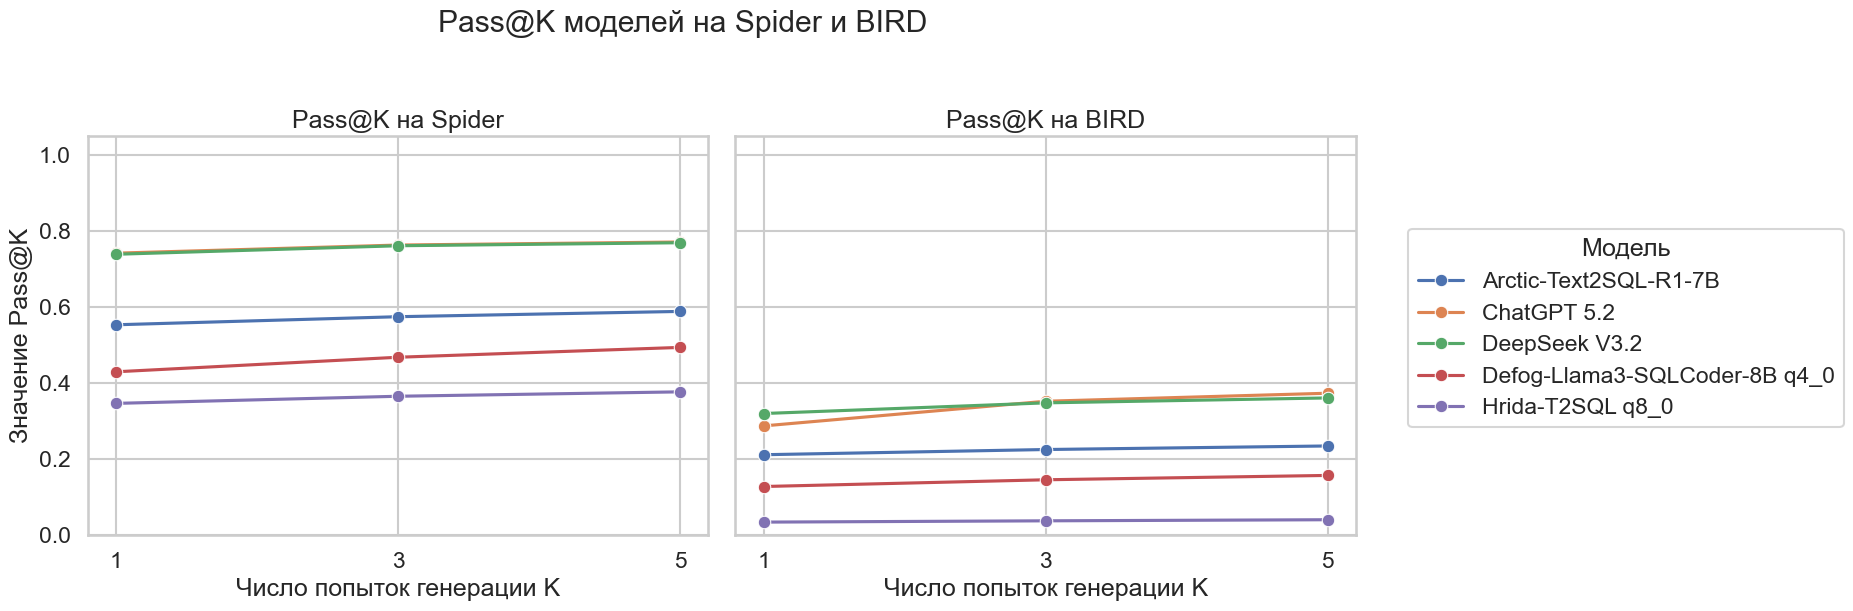

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/passk_by_model_ru.png


In [4]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
METRIC_LABELS = {
    'execution_accuracy': 'Execution Accuracy',
    'valid_sql_rate': 'Доля исполнимых SQL',
    'pass@1': 'Pass@1',
    'pass@3': 'Pass@3',
    'pass@5': 'Pass@5',
}

main_metrics = summary_df[['model_display_name', 'benchmark', 'execution_accuracy', *pass_metric_cols]].copy()
display(main_metrics.round(4))

passk_plot_df = summary_df.melt(
    id_vars=['model_display_name', 'benchmark'],
    value_vars=pass_metric_cols,
    var_name='metric',
    value_name='score',
).copy()
passk_plot_df['benchmark_ru'] = passk_plot_df['benchmark'].map(BENCHMARK_LABELS).fillna(passk_plot_df['benchmark'])
passk_plot_df['metric_ru'] = passk_plot_df['metric'].map(METRIC_LABELS).fillna(passk_plot_df['metric'])
passk_plot_df['k'] = passk_plot_df['metric'].str.extract(r'pass@(\d+)').astype(int)

benchmarks = [label for label in ['Spider', 'BIRD'] if label in set(passk_plot_df['benchmark_ru'])]
if not benchmarks:
    benchmarks = sorted(passk_plot_df['benchmark_ru'].dropna().unique().tolist())
fig, axes = plt.subplots(1, len(benchmarks), figsize=(7 * len(benchmarks), 6), sharey=True)
if len(benchmarks) == 1:
    axes = [axes]

for ax, benchmark_ru in zip(axes, benchmarks):
    subset = passk_plot_df[passk_plot_df['benchmark_ru'] == benchmark_ru].sort_values(['model_display_name', 'k'])
    sns.lineplot(
        data=subset,
        x='k',
        y='score',
        hue='model_display_name',
        marker='o',
        ax=ax,
    )
    ax.set_title(f'Pass@K на {benchmark_ru}')
    ax.set_xlabel('Число попыток генерации K')
    ax.set_ylabel('Значение Pass@K')
    ax.set_xticks(sorted(subset['k'].unique()))
    ax.set_ylim(0, 1.05)
    if ax.legend_ is not None:
        ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Модель', bbox_to_anchor=(1.01, 0.5), loc='center left')
fig.suptitle('Pass@K моделей на Spider и BIRD', y=1.03)
fig.tight_layout()
figure_path = FIGURES_DIR / 'passk_by_model_ru.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Сохранён файл: {figure_path}')


Кривые позволяют сравнивать не только итоговое значение `Pass@5`, но и характер прироста. Если линия быстро выходит на плато, дополнительные попытки почти не добавляют корректных SQL-запросов. Если рост продолжается, модель потенциально выигрывает от выбора лучшего кандидата среди нескольких генераций. Панели Spider и BIRD разделены, чтобы не смешивать наборы данных разной сложности.


## 4. Вычислительный профиль

Режим `pass_k` требует нескольких генераций на одну задачу, поэтому вычислительные характеристики особенно важны. В этом разделе показываются время инференса, число токенов, оценочная стоимость и интегральная эффективность в условиях многократной генерации.


,model_display_name,benchmark,Tinf,Tok,Cost,Eff_normalized,benchmark_ru
0,Arctic-Text2SQL-R1-7B,bird,1937.2883,1071.0722,0.0000,0.3568,BIRD
1,Arctic-Text2SQL-R1-7B,spider,1494.2570,554.7801,0.0000,0.1301,Spider
2,ChatGPT 5.2,bird,2186.9951,1020.6653,0.0019,0.7737,BIRD
3,ChatGPT 5.2,spider,1988.8856,479.0157,0.0009,0.3759,Spider
4,DeepSeek V3.2,bird,2950.7056,1051.6192,0.0003,0.5512,BIRD
5,DeepSeek V3.2,spider,2284.4739,514.8803,0.0001,0.2551,Spider
6,Defog-Llama3-SQLCoder-8B q4_0,bird,1625.6853,1010.0583,0.0000,0.2954,BIRD
7,Defog-Llama3-SQLCoder-8B q4_0,spider,1235.2643,483.0476,0.0000,0.0722,Spider
8,Hrida-T2SQL q8_0,bird,1344.5231,1403.7138,0.0000,0.3855,BIRD
9,Hrida-T2SQL q8_0,spider,704.0450,720.3383,0.0000,0.0783,Spider


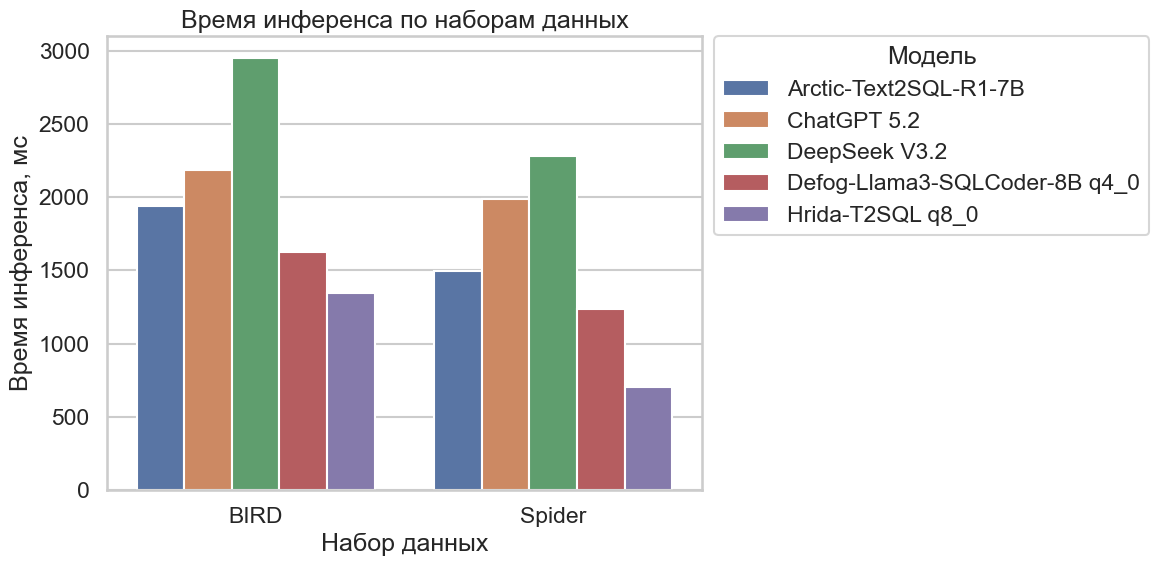

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/eff_latency_ru.png


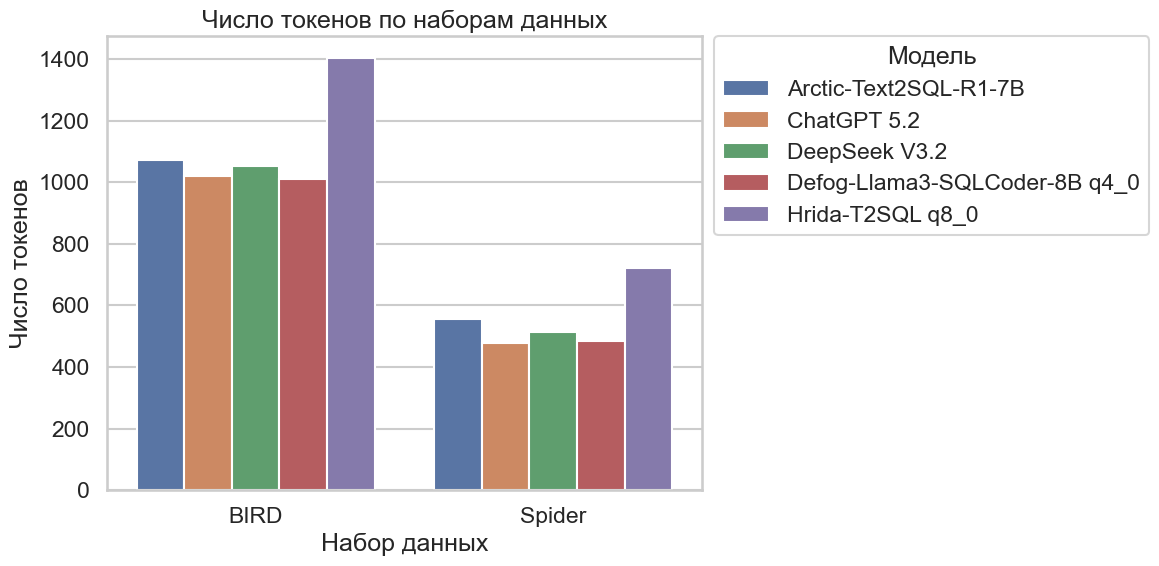

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/eff_tokens_ru.png


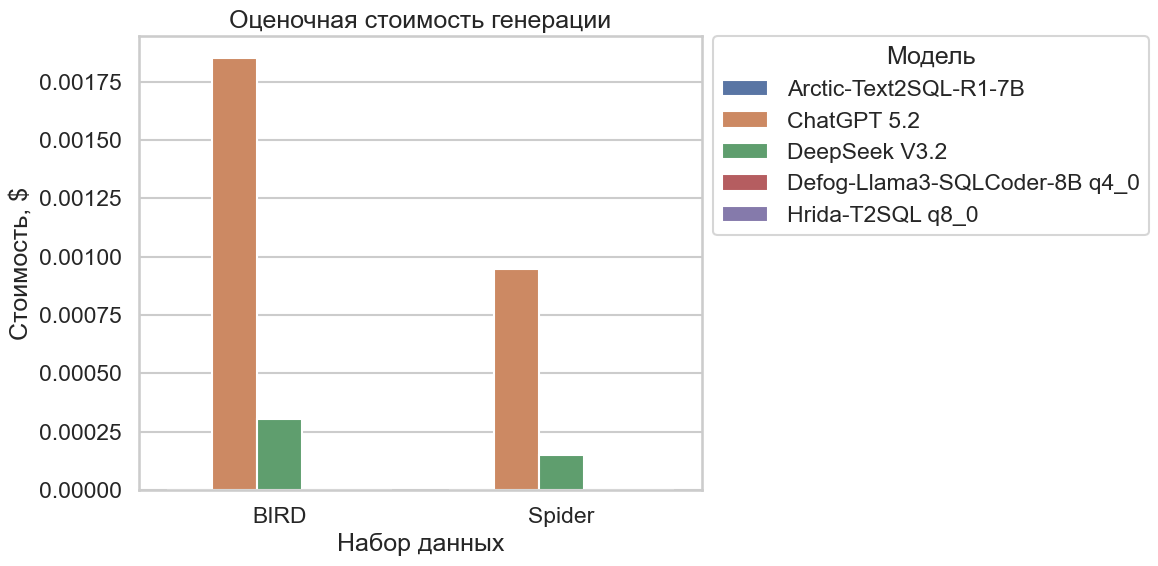

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/eff_cost_ru.png


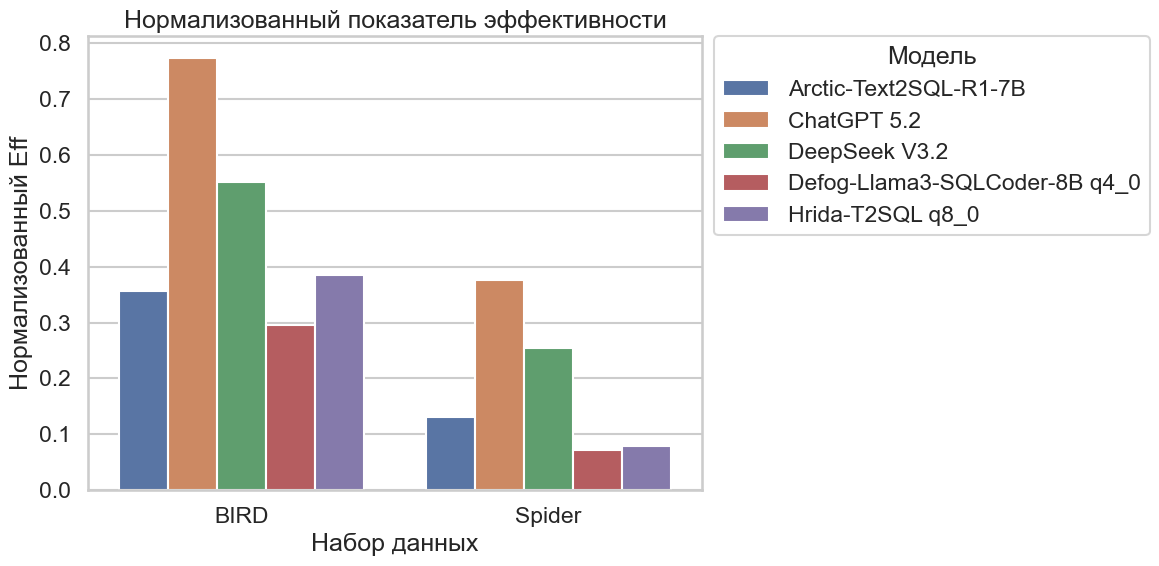

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/eff_normalized_ru.png
Созданные графики вычислительного профиля:
/home/count/code/vkr/results/nl2sql/figures/pass_k/eff_latency_ru.png
/home/count/code/vkr/results/nl2sql/figures/pass_k/eff_tokens_ru.png
/home/count/code/vkr/results/nl2sql/figures/pass_k/eff_cost_ru.png
/home/count/code/vkr/results/nl2sql/figures/pass_k/eff_normalized_ru.png


In [5]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

eff_df = summary_df[['model_display_name', 'benchmark', 'Tinf', 'Tok', 'Cost', 'Eff_normalized']].copy()
eff_df['benchmark_ru'] = eff_df['benchmark'].map(BENCHMARK_LABELS).fillna(eff_df['benchmark'])
display(eff_df.round(4))

metric_specs = [
    ('Tinf', 'Время инференса по наборам данных', 'Время инференса, мс', 'eff_latency_ru.png'),
    ('Tok', 'Число токенов по наборам данных', 'Число токенов', 'eff_tokens_ru.png'),
    ('Cost', 'Оценочная стоимость генерации', 'Стоимость, $', 'eff_cost_ru.png'),
]
created_figures = []
for column, title, ylabel, filename in metric_specs:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=eff_df, x='benchmark_ru', y=column, hue='model_display_name', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Набор данных')
    ax.set_ylabel(ylabel)
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / filename
    _save_current(fig, path)
    created_figures.append(path)

if summary_df['Eff_normalized'].notna().any():
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=eff_df, x='benchmark_ru', y='Eff_normalized', hue='model_display_name', ax=ax)
    ax.set_title('Нормализованный показатель эффективности')
    ax.set_xlabel('Набор данных')
    ax.set_ylabel('Нормализованный Eff')
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / 'eff_normalized_ru.png'
    _save_current(fig, path)
    created_figures.append(path)

print('Созданные графики вычислительного профиля:')
for path in created_figures:
    print(path)


## 5. Парные сравнения моделей

Парные сравнения рассчитываются на общем наборе задач. Они позволяют оценить, сохраняются ли различия между моделями при переходе от агрегированных средних к сопоставлению на уровне отдельных примеров.


,benchmark,benchmark_ru,left_model,right_model,pair,left_accuracy,right_accuracy,accuracy_diff,ci_low,ci_high,left_only_correct,right_only_correct
0,bird,BIRD,Arctic-Text2SQL-R1-7B,ChatGPT 5.2,Arctic-Text2SQL-R1-7B vs ChatGPT 5.2,0.2132,0.2868,-0.0737,-0.0952,-0.0522,121,234
1,bird,BIRD,Arctic-Text2SQL-R1-7B,DeepSeek V3.2,Arctic-Text2SQL-R1-7B vs DeepSeek V3.2,0.2132,0.3175,-0.1043,-0.1271,-0.0815,98,258
2,bird,BIRD,Arctic-Text2SQL-R1-7B,Defog-Llama3-SQLCoder-8B q4_0,Arctic-Text2SQL-R1-7B vs Defog-Llama3-SQLCoder...,0.2132,0.1258,0.0874,0.0671,0.1063,205,71
3,bird,BIRD,Arctic-Text2SQL-R1-7B,Hrida-T2SQL q8_0,Arctic-Text2SQL-R1-7B vs Hrida-T2SQL q8_0,0.2132,0.0378,0.1754,0.1532,0.1962,294,25
4,bird,BIRD,ChatGPT 5.2,DeepSeek V3.2,ChatGPT 5.2 vs DeepSeek V3.2,0.2868,0.3175,-0.0306,-0.0522,-0.0085,115,162
5,bird,BIRD,ChatGPT 5.2,Defog-Llama3-SQLCoder-8B q4_0,ChatGPT 5.2 vs Defog-Llama3-SQLCoder-8B q4_0,0.2868,0.1258,0.1610,0.1375,0.1852,312,65
6,bird,BIRD,ChatGPT 5.2,Hrida-T2SQL q8_0,ChatGPT 5.2 vs Hrida-T2SQL q8_0,0.2868,0.0378,0.2490,0.2262,0.2719,400,18
7,bird,BIRD,DeepSeek V3.2,Defog-Llama3-SQLCoder-8B q4_0,DeepSeek V3.2 vs Defog-Llama3-SQLCoder-8B q4_0,0.3175,0.1258,0.1917,0.1688,0.2158,348,54
8,bird,BIRD,DeepSeek V3.2,Hrida-T2SQL q8_0,DeepSeek V3.2 vs Hrida-T2SQL q8_0,0.3175,0.0378,0.2797,0.2549,0.3031,447,18
9,bird,BIRD,Defog-Llama3-SQLCoder-8B q4_0,Hrida-T2SQL q8_0,Defog-Llama3-SQLCoder-8B q4_0 vs Hrida-T2SQL q8_0,0.1258,0.0378,0.0880,0.0717,0.1069,158,23


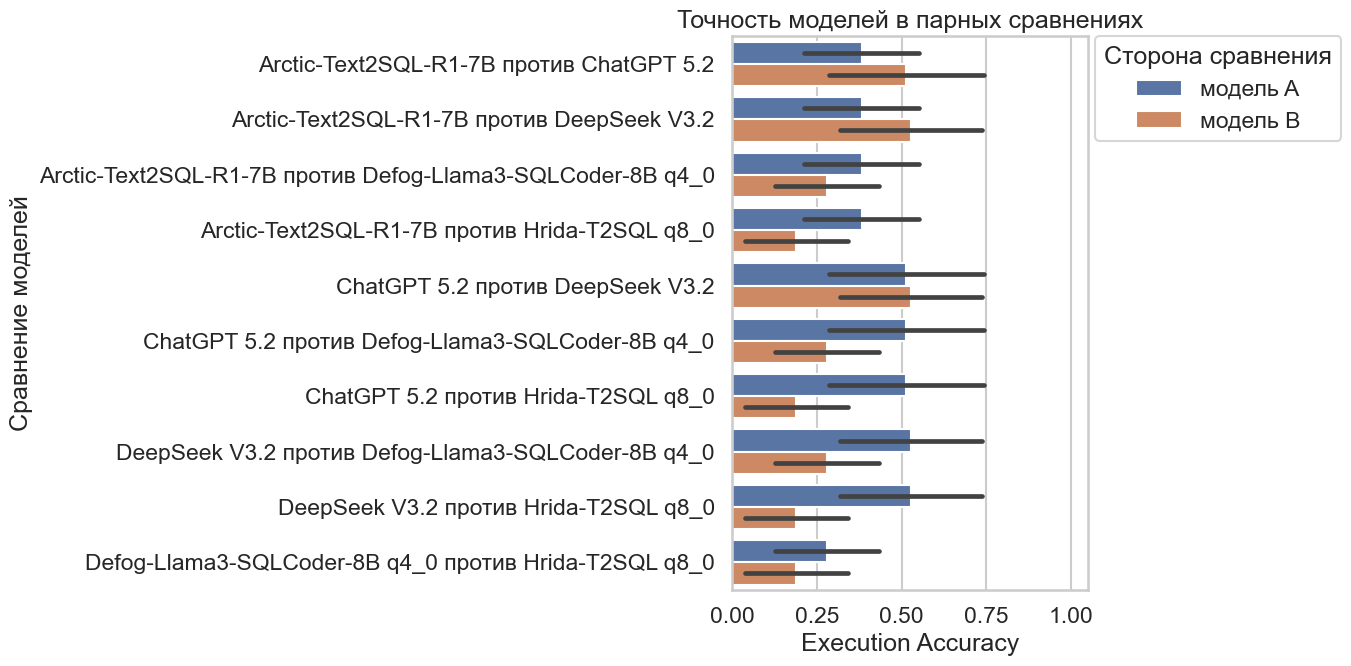

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/pairwise_accuracy_ru.png


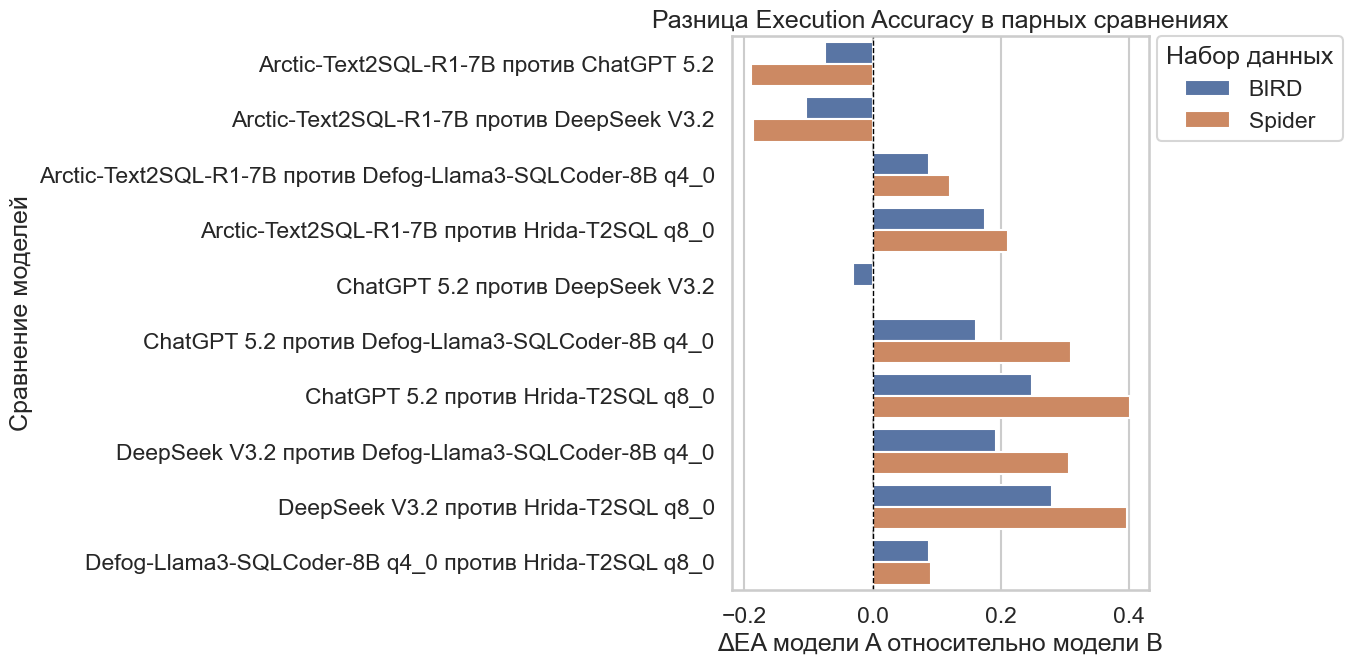

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/pairwise_delta_ru.png


In [6]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

from itertools import combinations

rows = []
for benchmark, group in outcomes_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_display_name', values='first_hit', aggfunc='first')
    model_names = list(pivot.columns)
    if len(model_names) < 2:
        continue

    for left, right in combinations(model_names, 2):
        left_vals = pivot[left].fillna(False).astype(bool)
        right_vals = pivot[right].fillna(False).astype(bool)
        diff = float(left_vals.mean() - right_vals.mean())

        diffs = []
        if len(pivot) > 1:
            pair_df = pd.DataFrame({'left': left_vals, 'right': right_vals})
            for _ in range(1000):
                sample = pair_df.sample(n=len(pair_df), replace=True)
                diffs.append(float(sample['left'].mean() - sample['right'].mean()))
            ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
        else:
            ci_low = ci_high = diff

        rows.append({
            'benchmark': benchmark,
            'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark),
            'left_model': left,
            'right_model': right,
            'pair': f'{left} vs {right}',
            'left_accuracy': float(left_vals.mean()),
            'right_accuracy': float(right_vals.mean()),
            'accuracy_diff': diff,
            'ci_low': float(ci_low),
            'ci_high': float(ci_high),
            'left_only_correct': int((left_vals & ~right_vals).sum()),
            'right_only_correct': int((~left_vals & right_vals).sum()),
        })

hyp_df = pd.DataFrame(rows)
display(hyp_df.round(4))

if not hyp_df.empty:
    accuracy_plot_df = hyp_df.melt(
        id_vars=['benchmark_ru', 'pair'],
        value_vars=['left_accuracy', 'right_accuracy'],
        var_name='side',
        value_name='accuracy',
    )
    accuracy_plot_df['side_ru'] = accuracy_plot_df['side'].map(SIDE_LABELS).fillna(accuracy_plot_df['side'])
    accuracy_plot_df['comparison_ru'] = accuracy_plot_df['pair'].str.replace(' vs ', ' против ', regex=False)

    fig, ax = plt.subplots(figsize=(14, max(7, 0.35 * len(accuracy_plot_df['comparison_ru'].unique()))))
    sns.barplot(data=accuracy_plot_df, y='comparison_ru', x='accuracy', hue='side_ru', ax=ax)
    ax.set_title('Точность моделей в парных сравнениях')
    ax.set_xlabel('Execution Accuracy')
    ax.set_ylabel('Сравнение моделей')
    ax.set_xlim(0, 1.05)
    _legend_outside(ax, 'Сторона сравнения')
    path = FIGURES_DIR / 'pairwise_accuracy_ru.png'
    _save_current(fig, path)

    delta_df = hyp_df.copy()
    delta_df['comparison_ru'] = delta_df['pair'].str.replace(' vs ', ' против ', regex=False)
    fig, ax = plt.subplots(figsize=(14, max(7, 0.28 * len(delta_df))))
    sns.barplot(data=delta_df, y='comparison_ru', x='accuracy_diff', hue='benchmark_ru', ax=ax)
    ax.axvline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title('Разница Execution Accuracy в парных сравнениях')
    ax.set_xlabel('ΔEA модели A относительно модели B')
    ax.set_ylabel('Сравнение моделей')
    _legend_outside(ax, 'Набор данных')
    path = FIGURES_DIR / 'pairwise_delta_ru.png'
    _save_current(fig, path)
else:
    print('Недостаточно моделей для построения парных сравнений.')


## 6. Анализ ошибок

Раздел фиксирует структуру неуспешных генераций и пересечение корректных ответов между моделями. Для режима `pass_k` это важно, поскольку корректный результат может появиться не в первом ответе, а среди последующих кандидатов.


,sample_id,benchmark,model_display_name,error_category,first_pred_error
0,bird_0,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN
1,bird_1,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN
2,bird_2,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN
3,bird_3,bird,Arctic-Text2SQL-R1-7B,execution_error,no such column: T2.FRPM_Count_K_12
4,bird_4,bird,Arctic-Text2SQL-R1-7B,wrong_result,NaN


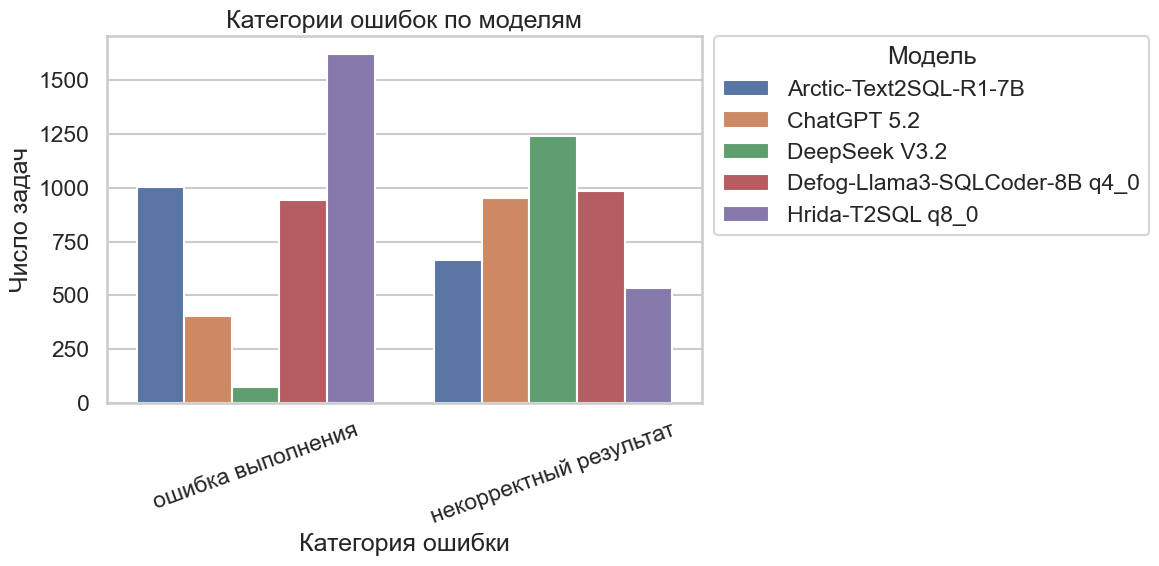

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/error_categories_ru.png


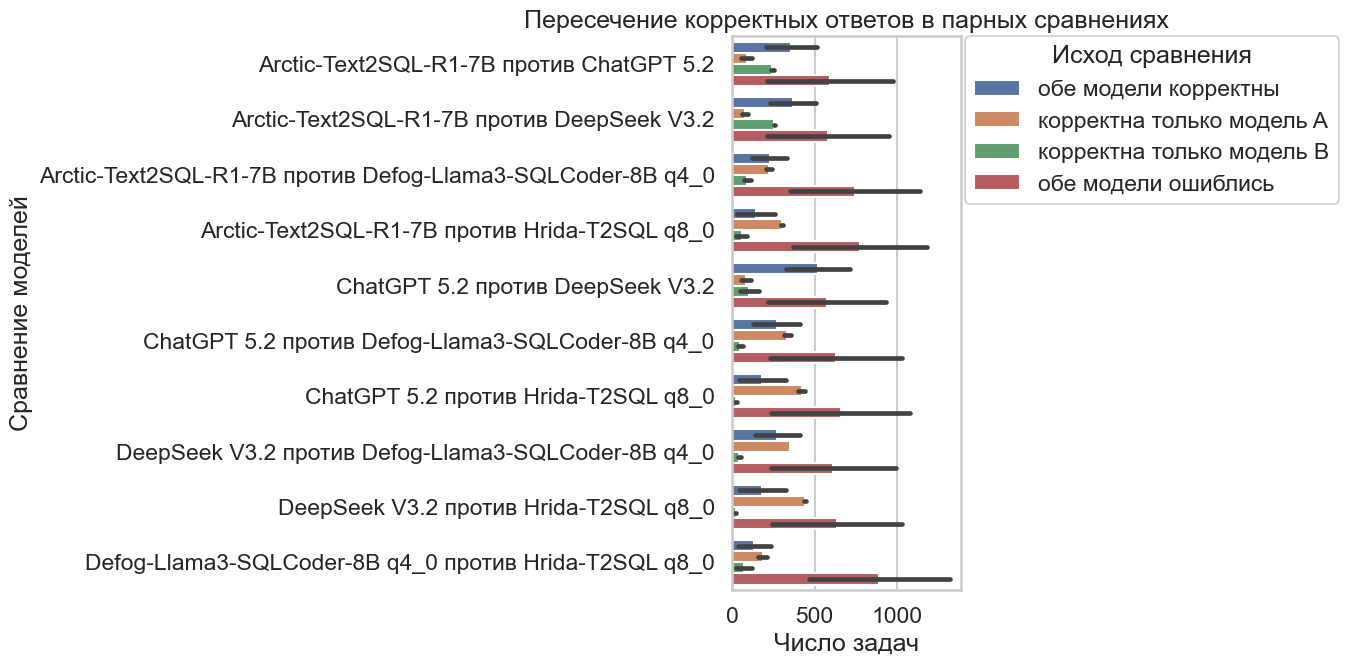

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/correctness_overlap_ru.png


,benchmark,model_display_name,sample_id,question,gold_sql,first_pred_sql,error_category,first_pred_error
0,bird,Arctic-Text2SQL-R1-7B,bird_0,What is the highest eligible free rate for K-1...,SELECT `Free Meal Count (K-12)` / `Enrollment ...,SELECT MAX(T1.`Percent (%) Eligible Free (K-12...,wrong_result,NaN
1,bird,Arctic-Text2SQL-R1-7B,bird_1,Please list the lowest three eligible free rat...,SELECT `Free Meal Count (Ages 5-17)` / `Enroll...,SELECT MIN(T2.`Percent (%) Eligible Free (Ages...,wrong_result,NaN
2,bird,Arctic-Text2SQL-R1-7B,bird_2,Please list the zip code of all the charter sc...,SELECT T2.Zip FROM frpm AS T1 INNER JOIN schoo...,SELECT Zip FROM schools WHERE Charter = 1 AND ...,wrong_result,NaN
3,bird,Arctic-Text2SQL-R1-7B,bird_3,What is the unabbreviated mailing street addre...,SELECT T2.MailStreet FROM frpm AS T1 INNER JOI...,SELECT T1.MailStreet FROM schools AS T1 INNER ...,execution_error,no such column: T2.FRPM_Count_K_12
4,bird,Arctic-Text2SQL-R1-7B,bird_4,Please list the phone numbers of the direct ch...,SELECT T2.Phone FROM frpm AS T1 INNER JOIN sch...,SELECT Phone FROM schools WHERE Charter = 1 AN...,wrong_result,NaN
5,bird,Arctic-Text2SQL-R1-7B,bird_5,How many schools with an average score in Math...,SELECT COUNT(DISTINCT T2.School) FROM satscore...,SELECT COUNT(*) FROM schools s JOIN satscores ...,wrong_result,NaN
8,bird,Arctic-Text2SQL-R1-7B,bird_8,What is the number of SAT test takers of the s...,SELECT NumTstTakr FROM satscores WHERE cds = (...,SELECT NumTstTakr FROM satscores WHERE cds IN ...,execution_error,no such column: FRPM_Count_k_12
9,bird,Arctic-Text2SQL-R1-7B,bird_9,Among the schools with the average score in Ma...,SELECT COUNT(T2.`School Code`) FROM satscores ...,SELECT COUNT(*) FROM schools WHERE CDSCode IN ...,execution_error,incomplete input
10,bird,Arctic-Text2SQL-R1-7B,bird_10,For the school with the highest average score ...,SELECT T2.`FRPM Count (Ages 5-17)` FROM satsco...,SELECT T1.`FRPM Count (Ages 5-17)` FROM frpm A...,wrong_result,NaN
11,bird,Arctic-Text2SQL-R1-7B,bird_11,Please list the codes of the schools with a to...,SELECT T2.CDSCode FROM schools AS T1 INNER JOI...,SELECT DISTINCT cds FROM satscores WHERE enrol...,wrong_result,NaN


In [7]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

from itertools import combinations

def categorize(row):
    if row['first_hit']:
        return 'correct'
    if row['empty_sql']:
        return 'empty_sql'
    if not row['first_pred_success']:
        return 'execution_error'
    return 'wrong_result'

error_df = outcomes_df.copy()
error_df['error_category'] = error_df.apply(categorize, axis=1)
error_df['error_category_ru'] = error_df['error_category'].map(ERROR_LABELS).fillna(error_df['error_category'])
error_df['benchmark_ru'] = error_df['benchmark'].map(BENCHMARK_LABELS).fillna(error_df['benchmark'])

display(error_df[['sample_id', 'benchmark', 'model_display_name', 'error_category', 'first_pred_error']].head())

failures = error_df[error_df['error_category'] != 'correct'].copy()
if failures.empty:
    print('В текущем запуске ошибок нет: график категорий ошибок не создан.')
else:
    order = [label for label in ['пустой SQL', 'ошибка выполнения', 'некорректный результат'] if label in set(failures['error_category_ru'])]
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.countplot(data=failures, x='error_category_ru', hue='model_display_name', order=order or None, ax=ax)
    ax.set_title('Категории ошибок по моделям')
    ax.set_xlabel('Категория ошибки')
    ax.set_ylabel('Число задач')
    ax.tick_params(axis='x', rotation=20)
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / 'error_categories_ru.png'
    _save_current(fig, path)

comparison_rows = []
for benchmark, group in error_df.groupby('benchmark'):
    pivot = group.pivot_table(index='sample_id', columns='model_display_name', values='first_hit', aggfunc='first')
    model_names = list(pivot.columns)
    if len(model_names) < 2:
        continue
    for left, right in combinations(model_names, 2):
        left_vals = pivot[left].fillna(False).astype(bool)
        right_vals = pivot[right].fillna(False).astype(bool)
        comparison_rows.extend([
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': 'both_correct', 'count': int((left_vals & right_vals).sum())},
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': f'only_left', 'count': int((left_vals & ~right_vals).sum())},
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': f'only_right', 'count': int((~left_vals & right_vals).sum())},
            {'benchmark': benchmark, 'benchmark_ru': BENCHMARK_LABELS.get(benchmark, benchmark), 'pair': f'{left} vs {right}', 'bucket': 'neither_correct', 'count': int((~left_vals & ~right_vals).sum())},
        ])

comparison_df = pd.DataFrame(comparison_rows)
if comparison_df.empty:
    print('Недостаточно моделей для анализа пересечения корректных ответов.')
else:
    comparison_df['bucket_ru'] = comparison_df['bucket'].map({
        'both_correct': 'обе модели корректны',
        'only_left': 'корректна только модель A',
        'only_right': 'корректна только модель B',
        'neither_correct': 'обе модели ошиблись',
    }).fillna(comparison_df['bucket'])
    comparison_df['comparison_ru'] = comparison_df['pair'].str.replace(' vs ', ' против ', regex=False)
    fig, ax = plt.subplots(figsize=(14, max(7, 0.35 * comparison_df['comparison_ru'].nunique())))
    sns.barplot(data=comparison_df, y='comparison_ru', x='count', hue='bucket_ru', ax=ax)
    ax.set_title('Пересечение корректных ответов в парных сравнениях')
    ax.set_xlabel('Число задач')
    ax.set_ylabel('Сравнение моделей')
    _legend_outside(ax, 'Исход сравнения')
    path = FIGURES_DIR / 'correctness_overlap_ru.png'
    _save_current(fig, path)

error_examples = failures[[
    'benchmark', 'model_display_name', 'sample_id', 'question', 'gold_sql', 'first_pred_sql', 'error_category', 'first_pred_error'
]].head(20) if not failures.empty else pd.DataFrame()
error_examples


## 7. Экспертная разметка

Если файл экспертной разметки заполнен, здесь можно агрегировать оценки полноты, эффективности и читаемости SQL-запросов. При отсутствии заполненной разметки раздел используется только для проверки расположения шаблона и степени его заполненности.


,sample_id,model_name,benchmark,completeness,efficiency,readability,model_display_name,is_scored
0,bird_0,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,Arctic-Text2SQL-R1-7B,False
1,bird_1,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,Arctic-Text2SQL-R1-7B,False
2,bird_2,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,Arctic-Text2SQL-R1-7B,False
3,bird_3,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,Arctic-Text2SQL-R1-7B,False
4,bird_4,Arctic-Text2SQL-R1-7B,bird,NaN,NaN,NaN,Arctic-Text2SQL-R1-7B,False


,benchmark,model_display_name,scored_rows,total_rows,coverage,benchmark_ru
0,bird,Arctic-Text2SQL-R1-7B,0,1534,0.0,BIRD
1,bird,ChatGPT 5.2,0,1534,0.0,BIRD
2,bird,DeepSeek V3.2,0,1534,0.0,BIRD
3,bird,Defog-Llama3-SQLCoder-8B q4_0,0,1534,0.0,BIRD
4,bird,Hrida-T2SQL q8_0,0,1534,0.0,BIRD
5,spider,Arctic-Text2SQL-R1-7B,0,1034,0.0,Spider
6,spider,ChatGPT 5.2,0,1034,0.0,Spider
7,spider,DeepSeek V3.2,0,1034,0.0,Spider
8,spider,Defog-Llama3-SQLCoder-8B q4_0,0,1034,0.0,Spider
9,spider,Hrida-T2SQL q8_0,0,1034,0.0,Spider


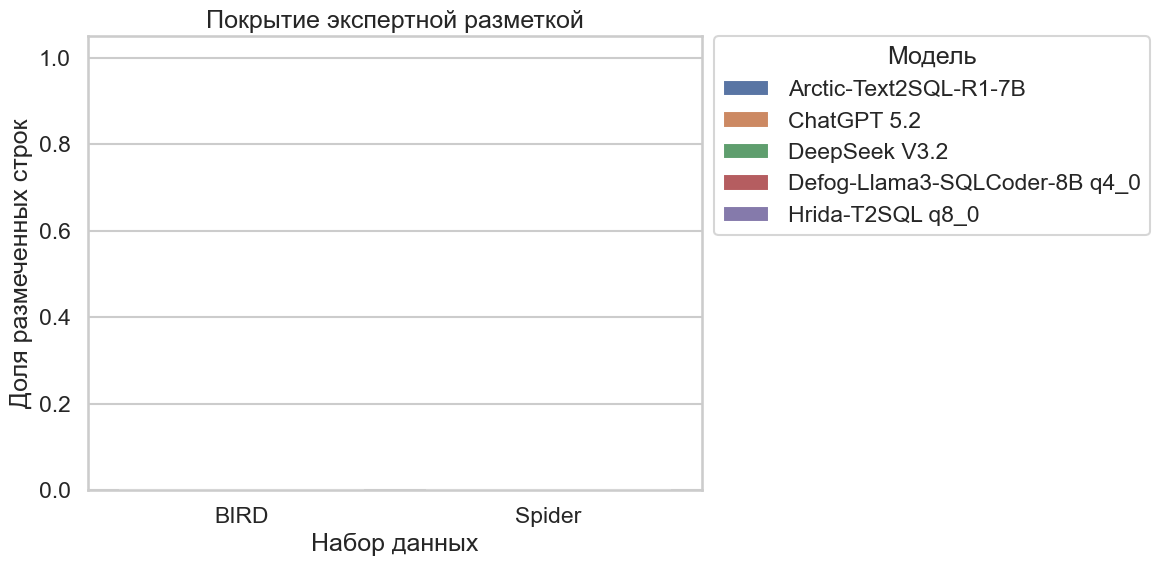

Сохранён файл: /home/count/code/vkr/results/nl2sql/figures/pass_k/expert_coverage_ru.png


In [8]:
BENCHMARK_LABELS = {
    'bird': 'BIRD',
    'spider': 'Spider',
    'synthetic_ecommerce': 'SEB',
}
DIFFICULTY_LABELS = {
    'easy': 'простые',
    'medium': 'средние',
    'hard': 'сложные',
    'simple': 'простые',
    'moderate': 'средние',
    'challenging': 'сложные',
}
ERROR_LABELS = {
    'correct': 'корректный результат',
    'empty_sql': 'пустой SQL',
    'execution_error': 'ошибка выполнения',
    'result_mismatch': 'некорректный результат',
    'wrong_result': 'некорректный результат',
}
BUCKET_LABELS = {
    'both_correct': 'обе модели корректны',
    'neither_correct': 'обе модели ошиблись',
}
SIDE_LABELS = {
    'left_accuracy': 'модель A',
    'right_accuracy': 'модель B',
}
MODEL_GROUP_LABELS = {
    'm1': 'M1',
    'm2': 'M2',
    'M1': 'M1',
    'M2': 'M2',
}

def _rotate_model_labels(ax, rotation=25):
    ax.tick_params(axis='x', rotation=rotation)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

def _legend_outside(ax, title):
    if ax.legend_ is not None:
        ax.legend(title=title, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

def _save_current(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Сохранён файл: {path}')

expert_df = pd.read_csv(expert_path) if Path(expert_path).exists() else pd.DataFrame()
if not expert_df.empty and 'model_display_name' not in expert_df.columns:
    display_map = outcomes_df[['model_name', 'model_display_name']].drop_duplicates()
    expert_df = expert_df.merge(display_map, on='model_name', how='left')
    expert_df['model_display_name'] = expert_df['model_display_name'].fillna(expert_df['model_name'])

score_cols = ['completeness', 'efficiency', 'readability']
for col in score_cols:
    if col not in expert_df.columns:
        expert_df[col] = pd.NA

expert_df['is_scored'] = expert_df[score_cols].notna().all(axis=1) if not expert_df.empty else pd.Series(dtype=bool)
display(expert_df.head())

if not expert_df.empty:
    coverage = (
        expert_df.groupby(['benchmark', 'model_display_name'])['is_scored']
        .agg(['sum', 'count'])
        .reset_index()
        .rename(columns={'sum': 'scored_rows', 'count': 'total_rows'})
    )
    coverage['coverage'] = coverage['scored_rows'] / coverage['total_rows'].clip(lower=1)
    coverage['benchmark_ru'] = coverage['benchmark'].map(BENCHMARK_LABELS).fillna(coverage['benchmark'])
    display(coverage.round(3))

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=coverage, x='benchmark_ru', y='coverage', hue='model_display_name', ax=ax)
    ax.set_title('Покрытие экспертной разметкой')
    ax.set_xlabel('Набор данных')
    ax.set_ylabel('Доля размеченных строк')
    ax.set_ylim(0, 1.05)
    _legend_outside(ax, 'Модель')
    path = FIGURES_DIR / 'expert_coverage_ru.png'
    _save_current(fig, path)
else:
    print('Файл экспертной разметки пуст или отсутствует.')


## 8. Выводы

Итоговый блок связывает качество многократной генерации с её вычислительной стоимостью. Выводы из этого ноутбука относятся к режиму `pass_k` и не подменяют основной анализ `Execution Accuracy` в режиме одного ответа.


In [9]:
final_pass_col = pass_metric_cols[-1] if pass_metric_cols else None
conclusion_cols = ['model_display_name', 'benchmark', 'execution_accuracy', 'Tinf', 'Tok', 'Cost']
if final_pass_col is not None:
    conclusion_cols.insert(3, final_pass_col)
conclusions = summary_df[conclusion_cols].copy()
conclusions = conclusions.sort_values(['benchmark', 'execution_accuracy'], ascending=[True, False])
conclusions.round(4)


,model_display_name,benchmark,execution_accuracy,pass@5,Tinf,Tok,Cost
4,DeepSeek V3.2,bird,0.3175,0.3611,2950.7056,1051.6192,0.0003
2,ChatGPT 5.2,bird,0.2868,0.3735,2186.9951,1020.6653,0.0019
0,Arctic-Text2SQL-R1-7B,bird,0.2132,0.2347,1937.2883,1071.0722,0.0000
6,Defog-Llama3-SQLCoder-8B q4_0,bird,0.1258,0.1571,1625.6853,1010.0583,0.0000
8,Hrida-T2SQL q8_0,bird,0.0378,0.0404,1344.5231,1403.7138,0.0000
3,ChatGPT 5.2,spider,0.7418,0.7718,1988.8856,479.0157,0.0009
5,DeepSeek V3.2,spider,0.7379,0.7698,2284.4739,514.8803,0.0001
1,Arctic-Text2SQL-R1-7B,spider,0.5522,0.5890,1494.2570,554.7801,0.0000
7,Defog-Llama3-SQLCoder-8B q4_0,spider,0.4323,0.4942,1235.2643,483.0476,0.0000
9,Hrida-T2SQL q8_0,spider,0.3414,0.3772,704.0450,720.3383,0.0000
